# SDF 데이터 도착 주기 분석

## 목표
- organized_by_sensor 폴더의 각 센서별 도착 주기 분포 분석
- 평균과 멀리 떨어진 수치(이상치) 개수 파악
- 센서별 데이터 수집 패턴 비교

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# 데이터 경로 설정
base_path = "/Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor"
sensor_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f)) and f != '.git']

print(f"발견된 센서 폴더: {len(sensor_folders)}개")
for folder in sorted(sensor_folders):
    print(f"  - {folder}")

발견된 센서 폴더: 7개
  - AGS_Green_7동_모터제어
  - AGS_Green_7동_온습도_입구근처20M
  - AGS_Green_8동_모터제어
  - AGS_Green_8동_온습도_입구근처20M
  - AGS_Green_강우
  - AGS_Green_외부온습도
  - AGS_Green_풍향풍속


In [3]:
# CSV 데이터 로드 함수
def load_csv_data(file_path):
    """CSV 파일 로드 및 타임스탬프 변환"""
    try:
        df = pd.read_csv(file_path)
        
        # 타임스탬프 컬럼 변환 (ts 또는 timestamp)
        ts_col = 'ts' if 'ts' in df.columns else 'timestamp'
        if ts_col in df.columns:
            df['timestamp'] = pd.to_datetime(df[ts_col], format='ISO8601')
            df = df.dropna(subset=['timestamp'])
            df = df.sort_values('timestamp').reset_index(drop=True)
        else:
            print(f"타임스탬프 컬럼 없음: {file_path}")
            return None
            
        return df
    except Exception as e:
        print(f"파일 로드 오류 {file_path}: {e}")
        return None

In [4]:
# 도착 주기 계산 함수
def calculate_intervals(df):
    """도착 주기(초) 계산"""
    if len(df) < 2:
        return np.array([])
    
    timestamps = df['timestamp'].values
    intervals = np.diff(timestamps).astype('timedelta64[s]').astype(float)
    
    return intervals

In [5]:
# 이상치 탐지 함수
def detect_outliers(intervals, method='iqr'):
    """도착 주기 이상치 탐지"""
    if len(intervals) == 0:
        return np.array([]), np.array([])
    
    if method == 'iqr':
        Q1 = np.percentile(intervals, 25)
        Q3 = np.percentile(intervals, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = intervals[(intervals < lower_bound) | (intervals > upper_bound)]
        normal = intervals[(intervals >= lower_bound) & (intervals <= upper_bound)]
    
    elif method == 'zscore':
        mean = np.mean(intervals)
        std = np.std(intervals)
        z_scores = np.abs((intervals - mean) / std)
        outliers = intervals[z_scores > 2]
        normal = intervals[z_scores <= 2]
    
    return normal, outliers

In [6]:
# 모든 센서 데이터 분석
all_results = {}

for sensor_folder in sorted(sensor_folders):
    folder_path = os.path.join(base_path, sensor_folder)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    print(f"\n{'='*60}")
    print(f"분석: {sensor_folder}")
    print(f"파일 수: {len(csv_files)}개")
    
    sensor_results = {
        'folder': sensor_folder,
        'files': [],
        'all_intervals': [],
        'statistics': {}
    }
    
    for csv_file in csv_files:
        file_name = os.path.basename(csv_file)
        print(f"  파일: {file_name}")
        
        df = load_csv_data(csv_file)
        if df is not None:
            intervals = calculate_intervals(df)
            
            if len(intervals) > 0:
                normal, outliers = detect_outliers(intervals)
                
                file_result = {
                    'file_name': file_name,
                    'data_points': len(df),
                    'intervals_count': len(intervals),
                    'mean_interval': np.mean(intervals),
                    'std_interval': np.std(intervals),
                    'median_interval': np.median(intervals),
                    'normal_count': len(normal),
                    'outlier_count': len(outliers),
                    'outlier_percentage': len(outliers) / len(intervals) * 100,
                    'outlier_values': outliers.tolist(),
                    'time_span': (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600  # 시간
                }
                
                sensor_results['files'].append(file_result)
                sensor_results['all_intervals'].extend(intervals.tolist())
                
                print(f"    데이터 포인트: {len(df):,}")
                print(f"    도착 주기: {np.mean(intervals):.2f}±{np.std(intervals):.2f}초")
                print(f"    이상치: {len(outliers)}개 ({len(outliers)/len(intervals)*100:.1f}%)")
            else:
                print(f"    도착 주기 계산 불가")
        else:
            print(f"    파일 로드 실패")
    
    # 센서 전체 통계
    if sensor_results['all_intervals']:
        all_intervals = np.array(sensor_results['all_intervals'])
        normal_all, outliers_all = detect_outliers(all_intervals)
        
        sensor_results['statistics'] = {
            'total_intervals': len(all_intervals),
            'mean_interval': np.mean(all_intervals),
            'std_interval': np.std(all_intervals),
            'median_interval': np.median(all_intervals),
            'normal_count': len(normal_all),
            'outlier_count': len(outliers_all),
            'outlier_percentage': len(outliers_all) / len(all_intervals) * 100,
            'min_interval': np.min(all_intervals),
            'max_interval': np.max(all_intervals),
        }
        
        print(f"\n📊 {sensor_folder} 전체 통계:")
        print(f"  총 도착 주기 데이터: {len(all_intervals):,}개")
        print(f"  평균 도착 주기: {np.mean(all_intervals):.2f}±{np.std(all_intervals):.2f}초")
        print(f"  범위: {np.min(all_intervals):.1f}초 ~ {np.max(all_intervals):.1f}초")
        print(f"  이상치: {len(outliers_all)}개 ({len(outliers_all)/len(all_intervals)*100:.1f}%)")
    
    all_results[sensor_folder] = sensor_results


분석: AGS_Green_7동_모터제어
파일 수: 8개
  파일: In_agsmotor_green_UUID_000003_ch8_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch1_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch3_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch2_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch4_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch5_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch6_20260318_170208.csv
    데이터 포인트: 46,277
    도착 주기: 53.42±108.49초
    이상치: 9876개 (21.3%)
  파일: In_agsmotor_green_UUID_000003_ch7_20260318_170208.csv
    데이터 포인트:

## 이상치 상세 분석

In [7]:
# 이상치 상세 분석 보고서
print("\n" + "="*80)
print("이상치 상세 분석 보고서")
print("="*80)

outlier_summary = []

for sensor_name, results in all_results.items():
    if 'statistics' in results and results['statistics']['outlier_count'] > 0:
        stats = results['statistics']
        
        # 이상치 범위 분석
        all_intervals = np.array(results['all_intervals'])
        normal, outliers = detect_outliers(all_intervals)
        
        if len(outliers) > 0:
            outlier_summary.append({
                'sensor': sensor_name.replace('AGS_Green_', ''),
                'total_intervals': stats['total_intervals'],
                'outlier_count': stats['outlier_count'],
                'outlier_percentage': stats['outlier_percentage'],
                'mean_interval': stats['mean_interval'],
                'outlier_min': np.min(outliers),
                'outlier_max': np.max(outliers),
                'outlier_range': np.max(outliers) - np.min(outliers)
            })

# 이상치가 많은 순서로 정렬
outlier_summary_df = pd.DataFrame(outlier_summary).sort_values('outlier_percentage', ascending=False)

print("\n🔍 이상치 발생률 높은 센서 TOP 5:")
for i, row in outlier_summary_df.head().iterrows():
    print(f"{i+1}. {row['sensor']}: {row['outlier_count']}개 ({row['outlier_percentage']:.1f}%)")
    print(f"   평균 주기: {row['mean_interval']:.2f}초")
    print(f"   이상치 범위: {row['outlier_min']:.1f}초 ~ {row['outlier_max']:.1f}초")
    print()


이상치 상세 분석 보고서

🔍 이상치 발생률 높은 센서 TOP 5:
1. 7동_모터제어: 79008개 (21.3%)
   평균 주기: 53.42초
   이상치 범위: 15.0초 ~ 7229.0초

3. 8동_모터제어: 78360개 (21.2%)
   평균 주기: 53.51초
   이상치 범위: 16.0초 ~ 7229.0초

2. 7동_온습도_입구근처20M: 466개 (1.8%)
   평균 주기: 97.93초
   이상치 범위: 6.0초 ~ 7216.0초

4. 8동_온습도_입구근처20M: 466개 (1.8%)
   평균 주기: 97.93초
   이상치 범위: 6.0초 ~ 7216.0초

5. 강우: 466개 (1.8%)
   평균 주기: 97.93초
   이상치 범위: 6.0초 ~ 7216.0초



## 시각화

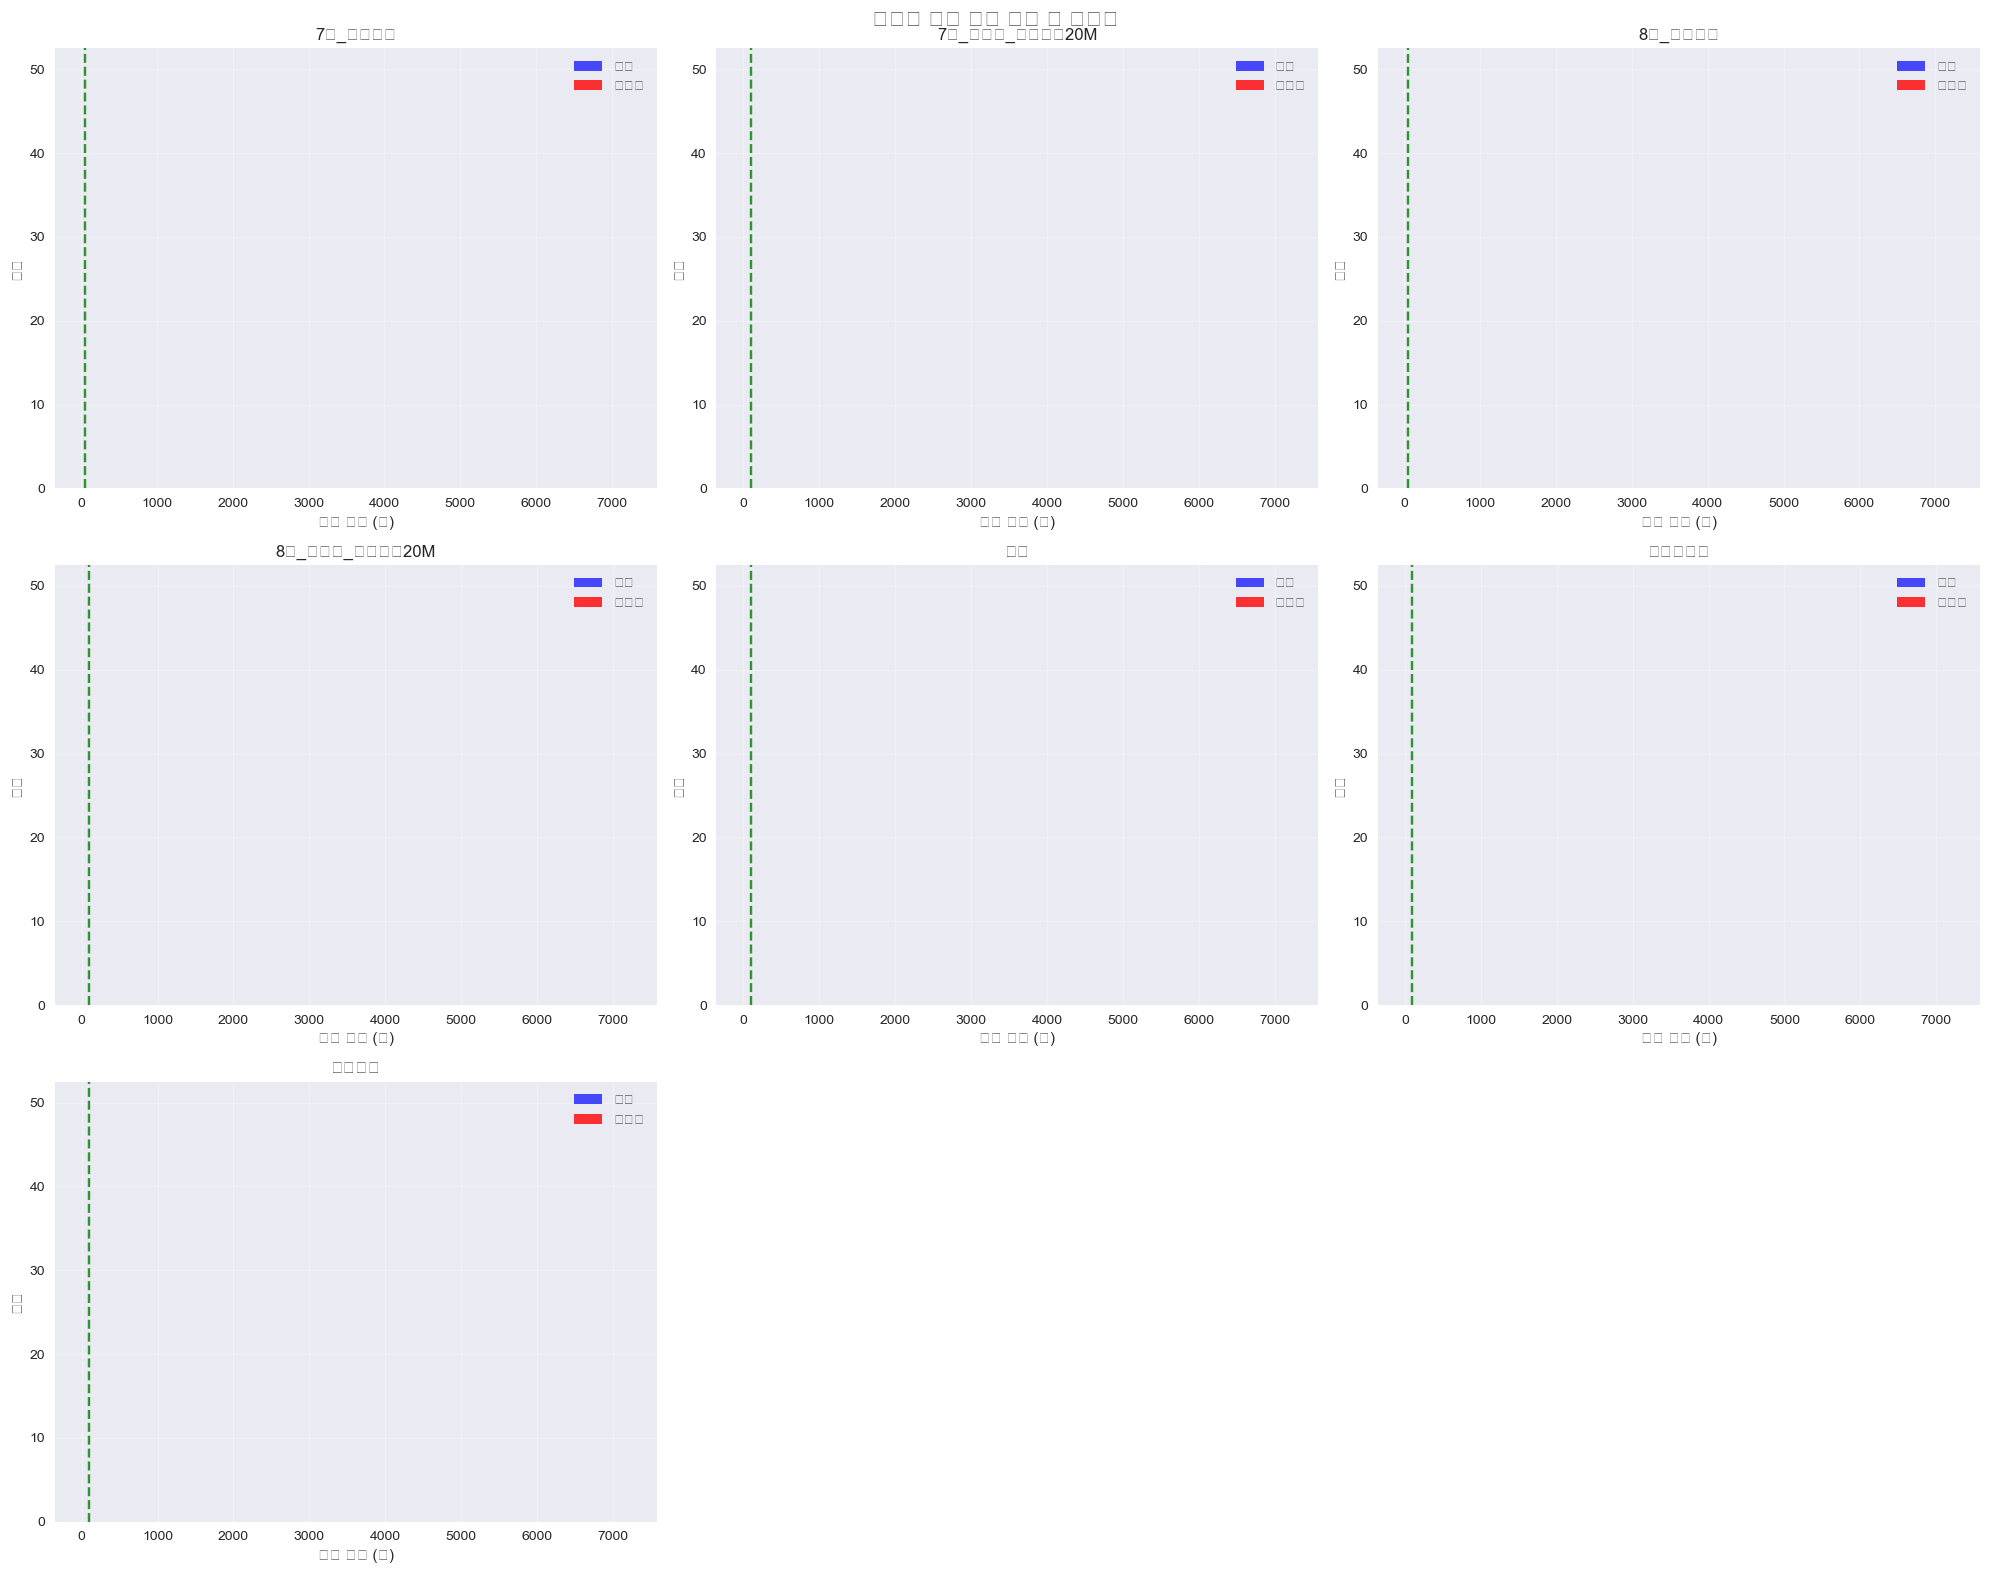

In [8]:
# 도착 주기 분포 시각화
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('센서별 도착 주기 분포 및 이상치', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (sensor_name, results) in enumerate(all_results.items()):
    if idx >= 9:  # 최대 9개 센서만 표시
        break
        
    if 'statistics' in results:
        all_intervals = np.array(results['all_intervals'])
        normal, outliers = detect_outliers(all_intervals)
        
        # 히스토그램
        axes[idx].hist(normal, bins=50, alpha=0.7, color='blue', label='정상', density=True)
        if len(outliers) > 0:
            axes[idx].hist(outliers, bins=30, alpha=0.8, color='red', label='이상치', density=True)
        
        axes[idx].set_title(f"{sensor_name.replace('AGS_Green_', '')}")
        axes[idx].set_xlabel('도착 주기 (초)')
        axes[idx].set_ylabel('밀도')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # 평균선 표시
        mean_val = results['statistics']['mean_interval']
        axes[idx].axvline(mean_val, color='green', linestyle='--', alpha=0.8, label=f'평균: {mean_val:.1f}s')

# 남은 빈 subplot 숨기기
for idx in range(len(all_results), 9):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

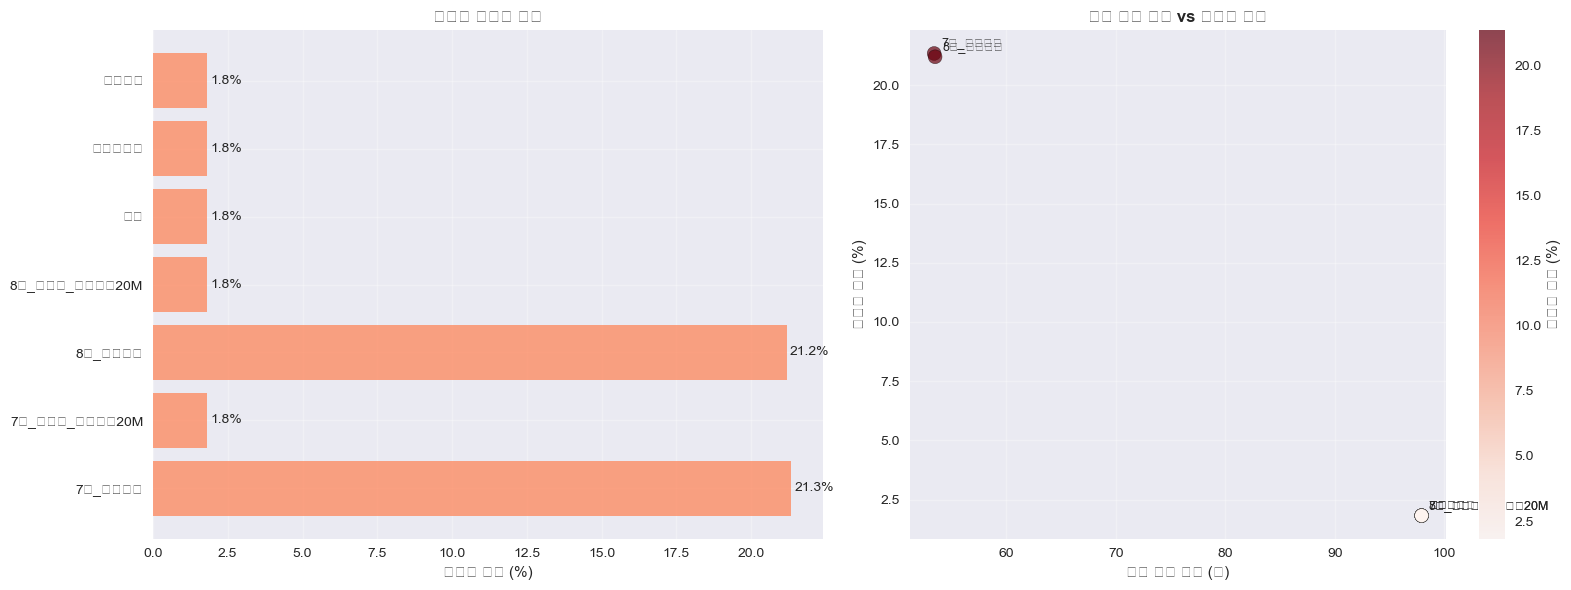

In [9]:
# 이상치 비율 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 이상치 비율 막대그래프
sensor_names = [s.replace('AGS_Green_', '') for s in all_results.keys()]
outlier_percentages = [r['statistics']['outlier_percentage'] if 'statistics' in r else 0 for r in all_results.values()]

bars = ax1.barh(sensor_names, outlier_percentages, color='coral', alpha=0.7)
ax1.set_title('센서별 이상치 비율', fontweight='bold')
ax1.set_xlabel('이상치 비율 (%)')
ax1.grid(True, alpha=0.3)

# 값 표시
for i, (bar, percentage) in enumerate(zip(bars, outlier_percentages)):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{percentage:.1f}%', va='center', fontsize=10)

# 2. 평균 도착 주기 vs 이상치 비율 산점도
mean_intervals = [r['statistics']['mean_interval'] if 'statistics' in r else 0 for r in all_results.values()]

scatter = ax2.scatter(mean_intervals, outlier_percentages, 
                     s=100, alpha=0.7, c=outlier_percentages, 
                     cmap='Reds', edgecolors='black')

ax2.set_title('평균 도착 주기 vs 이상치 비율', fontweight='bold')
ax2.set_xlabel('평균 도착 주기 (초)')
ax2.set_ylabel('이상치 비율 (%)')
ax2.grid(True, alpha=0.3)

# 레이블 추가
for i, (x, y, name) in enumerate(zip(mean_intervals, outlier_percentages, sensor_names)):
    ax2.annotate(name, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)

# 컬러바 추가
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('이상치 비율 (%)')

plt.tight_layout()
plt.show()

## 종합 요약

In [10]:
# 종합 분석 요약
print("\n" + "="*80)
print("SDF 데이터 도착 주기 분석 종합 요약")
print("="*80)

total_intervals = sum(r['statistics']['total_intervals'] for r in all_results.values() if 'statistics' in r)
total_outliers = sum(r['statistics']['outlier_count'] for r in all_results.values() if 'statistics' in r)
overall_outlier_rate = total_outliers / total_intervals * 100 if total_intervals > 0 else 0

print(f"\n📊 전체 현황:")
print(f"  - 분석 센서 수: {len(all_results)}개")
print(f"  - 총 도착 주기 데이터: {total_intervals:,}개")
print(f"  - 총 이상치: {total_outliers:,}개")
print(f"  - 전체 이상치 비율: {overall_outlier_rate:.2f}%")

print(f"\n🎯 주요 발견사항:")

# 가장 높은 이상치 비율
highest_outlier = max(all_results.items(), 
                     key=lambda x: x[1]['statistics']['outlier_percentage'] if 'statistics' in x[1] else 0)
print(f"  1. 가장 높은 이상치 비율: {highest_outlier[0].replace('AGS_Green_', '')} ")
print(f"     ({highest_outlier[1]['statistics']['outlier_percentage']:.1f}%)")

# 가장 규칙적인 센서
most_regular = min(all_results.items(), 
                   key=lambda x: x[1]['statistics']['std_interval'] / x[1]['statistics']['mean_interval'] 
                   if 'statistics' in x[1] and x[1]['statistics']['mean_interval'] > 0 else float('inf'))
cv_regular = most_regular[1]['statistics']['std_interval'] / most_regular[1]['statistics']['mean_interval']
print(f"  2. 가장 규칙적인 도착 주기: {most_regular[0].replace('AGS_Green_', '')}")
print(f"     (변동계수: {cv_regular:.3f})")

# 가장 긴 도착 주기
longest_interval = max(all_results.items(), 
                       key=lambda x: x[1]['statistics']['mean_interval'] if 'statistics' in x[1] else 0)
print(f"  3. 가장 긴 평균 도착 주기: {longest_interval[0].replace('AGS_Green_', '')}")
print(f"     ({longest_interval[1]['statistics']['mean_interval']:.1f}초)")

# 가장 짧은 도착 주기
shortest_interval = min(all_results.items(), 
                        key=lambda x: x[1]['statistics']['mean_interval'] if 'statistics' in x[1] else float('inf'))
print(f"  4. 가장 짧은 평균 도착 주기: {shortest_interval[0].replace('AGS_Green_', '')}")
print(f"     ({shortest_interval[1]['statistics']['mean_interval']:.1f}초)")

print(f"\n💡 개선 권고사항:")
print(f"  1. 이상치 비율이 10% 이상인 센서들의 데이터 수집 시스템 점검")
print(f"  2. 도착 주기가 매우 긴 센서들의 수집 주기 최적화 검토")
print(f"  3. 변동계수가 높은 센서들의 네트워크 안정성 확보")
print(f"  4. 주기적인 데이터 동기화 품질 모니터링 시스템 구축")

print("\n" + "="*80)


SDF 데이터 도착 주기 분석 종합 요약

📊 전체 현황:
  - 분석 센서 수: 7개
  - 총 도착 주기 데이터: 867,670개
  - 총 이상치: 159,698개
  - 전체 이상치 비율: 18.41%

🎯 주요 발견사항:
  1. 가장 높은 이상치 비율: 7동_모터제어 
     (21.3%)
  2. 가장 규칙적인 도착 주기: 강우
     (변동계수: 1.089)
  3. 가장 긴 평균 도착 주기: 7동_온습도_입구근처20M
     (97.9초)
  4. 가장 짧은 평균 도착 주기: 7동_모터제어
     (53.4초)

💡 개선 권고사항:
  1. 이상치 비율이 10% 이상인 센서들의 데이터 수집 시스템 점검
  2. 도착 주기가 매우 긴 센서들의 수집 주기 최적화 검토
  3. 변동계수가 높은 센서들의 네트워크 안정성 확보
  4. 주기적인 데이터 동기화 품질 모니터링 시스템 구축

